Data cleaning in python is done using pandas,handling null values,dropping missing values,dropping columns with wrong data,filling null values,all these thing are part of cleaning


In [4]:
import pandas as pd
df=pd.read_csv("North America Restaurants (1).csv")

In [ ]:
#check entire data frame for missing values
#this returns tru/false for each value in the data frame
df.isna()

,name,city,state,zipcode,country,cuisines,pickup_enabled,delivery_enabled,weighted_rating_value,aggregated_rating_count
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False,False


In [ ]:
import pandas as pd
import numpy as np
data={
    'Employee':['Shashank','Rohit','Satyarth','Shyam','Ram'],
    'department':['IT','HR','IT','HR','Finance'],
    'age':[25,30,np.nan,28,np.nan],
    'salary':[50000,60000,55000,np.nan,45000],
    'performance':[85,78,90,np.nan,80]
}
df=pd.DataFrame(data)


In [16]:
df.isna()

,Employee,department,age,salary,performance
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,True,True
4,False,False,True,False,False


In [ ]:
df.isna().sum()   #to get the count of missing values in each column

Employee       0
department     0
age            2
salary         1
performance    1
dtype: int64

In [ ]:
#rows with missing columns
df[df.isna().any(axis=1)]

,Employee,department,age,salary,performance
2,Satyarth,IT,NaN,55000.0,90.0
3,Shyam,HR,28.0,NaN,NaN
4,Ram,Finance,NaN,45000.0,80.0


axis tell which directionto move in for pandas

rown -> moves horizontally
columns -> moves vertically

there are only two possible axes:
axis 0 =means operates down the rows(column-wise)
axis 1 = means operates across the columns(row-wise)


In [19]:
#dropping missing values
df.dropna()   #this will drop all the rows with missing values

,Employee,department,age,salary,performance
0,Shashank,IT,25.0,50000.0,85.0
1,Rohit,HR,30.0,60000.0,78.0


In [ ]:
df.dropna(how='all')
#drops any row where all values are missing
#how=all is strict deletion

,Employee,department,age,salary,performance
0,Shashank,IT,25.0,50000.0,85.0
1,Rohit,HR,30.0,60000.0,78.0
2,Satyarth,IT,NaN,55000.0,90.0
3,Shyam,HR,28.0,NaN,NaN
4,Ram,Finance,NaN,45000.0,80.0


In [22]:
#based on threshold
df.dropna(thresh=4)
#keeps rows with atleast 4 non-null values


,Employee,department,age,salary,performance
0,Shashank,IT,25.0,50000.0,85.0
1,Rohit,HR,30.0,60000.0,78.0
2,Satyarth,IT,NaN,55000.0,90.0
4,Ram,Finance,NaN,45000.0,80.0


In [23]:
df.dropna(axis=1)   #drops columns with missing values



,Employee,department
0,Shashank,IT
1,Rohit,HR
2,Satyarth,IT
3,Shyam,HR
4,Ram,Finance


Imputation - filling missing values
in python both np.nan and None aer the missing data

np.nan stands for not a number
None is for missing data

when do we drop?
1. drop when missing values are very small,
ex- dataset has 10,000 rows, only 20 rows contain missing values, dropping them won't affect analysis

2. entire column is useless or unnecessary data or maybe entire column is empty

when will dropping will be a problem?

when dropping we remove other valuable information too to avoid this we prefer filling in some cases

Types of imputation-
- mean imputation
- mode imputation
- median imputation
- time-series imputation

dropping can sometimes reduce dataset size and dropping them might not make sense

dropping is better when there are too many missing values in a column,
sometimes missing values might be important

ex-
in a loan dataset
income-NaN
loan default-yes

missing income means it might be risky to provide loan and dropping this row means losing important information

In [17]:
import pandas as pd
import numpy as np

data = {
    'customer_name': ['Shash', 'Bala', 'Deepa', 'Esha', 'Bala'],
    'city': ['Bangalore', 'Delhi', 'Delhi','Bangalore', 'Delhi'],
    'order_value': [5000, 7000, np.nan, 6500, 7200], # Removed the extra 7000
    'order_date': ['2024-01-01', '2024-01-02', None, '2024-01-05', '2024-04-05'],
    'Email': ['shash@gmail.com', 'bala@gmail.com', 'deepa@gmail.com',
             'esha@gmail.com', 'bala@gmail.com']   
}

df = pd.DataFrame(data)
print(df)

  customer_name       city  order_value  order_date            Email
0         Shash  Bangalore       5000.0  2024-01-01  shash@gmail.com
1          Bala      Delhi       7000.0  2024-01-02   bala@gmail.com
2         Deepa      Delhi          NaN         NaN  deepa@gmail.com
3          Esha  Bangalore       6500.0  2024-01-05   esha@gmail.com
4          Bala      Delhi       7200.0  2024-04-05   bala@gmail.com


40000,42000,45000,47000,50000
40000,42000,41000,43000,60000

10,20,30,40,50
      
      30      

    20    40  
10           50

mean=30
median=30
mode=30
- mean imputation
mean uses all data points and since data is balanced it represents the center of accurately

use when-
data is numerical
distribution is symmetric
no extreme outliers

ex- heights: 165,168,170,NaN,172
in this case we can fill with mean

salaries: 40000,42000,45000,47000,900000

outliers are extreme values that are very different from the rest of the data
the value 90000 is an outlier here
normal salaries: 40k-47k
outlier:900k
when there are outliers in the data mean will become distorted
and value will be distorted

skewed distribution
left-skewed
right-skewed

a distribution becomes skewed when outliers pull data towards one side

most values ->left side
one hue value ->right side

this is skewed distribution
mean gets dragges towards the right side

median will stay stable
median works better when
data is skewed
outliers exist
numeric data

mode imputation
mode=most frequent value
used for categorial data
cities: Bangalore,Delhi,Delhi,Mumbai,NaN
fill missing value with most common category

time series imputation

time series data has time order
date                        order
------                      ------    
day 1                       100
day 2                       NaN
day 3                       105

here we use forward fill or interpolation
day 2=day 1
because time changes gradually so yesterday's value is often the best estimate

use when data is time based
observations are sequential
values change gradually

ex-
stock prices
temperature sensors
electricity usage
website traffic



In [10]:
#missing order value
df['order_value'].fillna(df['order_value'].mean())
#replaced missing order value with average order value


0    5000.0
1    7000.0
2    6425.0
3    6500.0
4    7200.0
Name: order_value, dtype: float64

In [ ]:
#categorial data
df['city'].fillna(df['city'].mode()[0])
#when there are multiple modes
#[0] will fill it with the first entry

0    Bangalore
1        Delhi
2        Delhi
3    Bangalore
4        Delhi
Name: city, dtype: str

In [27]:
#time series data
#suppose daily order value is missing
df['order_date']=pd.to_datetime(df['order_date'])
df['order_date']=df['order_date'].ffill()
print(df)
#when it comes to date datatype it is best to convert the date column to datetime datatype
#because sometimes the date column might be set to strin type
#so you have to convert to datetime datatype


  customer_name       city  order_value order_date            Email
0         Shash  Bangalore       5000.0 2024-01-01  shash@gmail.com
1          Bala      Delhi       7000.0 2024-01-02   bala@gmail.com
2         Deepa      Delhi          NaN 2024-01-02  deepa@gmail.com
3          Esha  Bangalore       6500.0 2024-01-05   esha@gmail.com
4          Bala      Delhi       7200.0 2024-04-05   bala@gmail.com


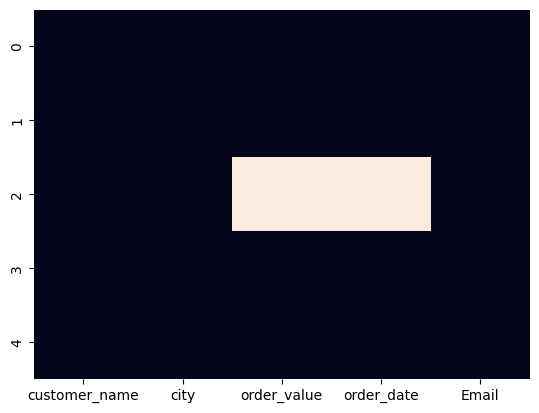

  customer_name       city  order_value  order_date            Email
0         Shash  Bangalore       5000.0  2024-01-01  shash@gmail.com
1          Bala      Delhi       7000.0  2024-01-02   bala@gmail.com
2         Deepa      Delhi          NaN         NaN  deepa@gmail.com
3          Esha  Bangalore       6500.0  2024-01-05   esha@gmail.com
4          Bala      Delhi       7200.0  2024-04-05   bala@gmail.com


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = {
    'customer_name': ['Shash', 'Bala', 'Deepa', 'Esha', 'Bala'],
    'city': ['Bangalore', 'Delhi', 'Delhi','Bangalore', 'Delhi'],
    'order_value': [5000, 7000, np.nan, 6500, 7200], # Removed the extra 7000
    'order_date': ['2024-01-01', '2024-01-02', None, '2024-01-05', '2024-04-05'],
    'Email': ['shash@gmail.com', 'bala@gmail.com', 'deepa@gmail.com',
             'esha@gmail.com', 'bala@gmail.com']   
}
df = pd.DataFrame(data)
sns.heatmap(df.isna(),cbar=False)   #heatmap is used as darker and lighter colour where the data exist more/less 
plt.show()
print(df)

sns.heatmap converts df.isna matrix here to colors so missing values appear as highlighted cells.

analysts use heatmaps in EDA (Exploratory Data Analysis)

cbar=color bar(legend)

cbar is set to false because we have only true or false values so color scale is unnecessary


In [25]:
#time series imputation
#interpolate

data={'order_date': ['2024-01-01', '2024-01-02', None, '2024-01-05', '2024-04-05'],
      'sales':[100,np.nan,110,np.nan,120]
}
df=pd.DataFrame(data)
df['order_date']=pd.to_datetime(df['order_date'])
df

,order_date,sales
0,2024-01-01,100.0
1,2024-01-02,NaN
2,NaT,110.0
3,2024-01-05,NaN
4,2024-04-05,120.0


In [18]:
df['sales']=df['sales'].ffill()
df

,order_date,sales
0,2024-01-01,100.0
1,2024-01-02,110.0
2,NaT,110.0
3,2024-01-05,120.0
4,2024-04-05,120.0


In [26]:
df['sales']=df['sales'].bfill()
df

,order_date,sales
0,2024-01-01,100.0
1,2024-01-02,110.0
2,NaT,110.0
3,2024-01-05,120.0
4,2024-04-05,120.0


In [27]:
#interpolation estimates the value between two known points
df['sales']=df['sales'].interpolate()
df

,order_date,sales
0,2024-01-01,100.0
1,2024-01-02,110.0
2,NaT,110.0
3,2024-01-05,120.0
4,2024-04-05,120.0
